Doing other 75 5
Doing idx 0 file /home/tomek/datasets/GuitarSet/05_Jazz1-130-D_comp_mic.wav, 1/360, length 22 sec
Elapsed time pitch: 0.44381165504455566


/home/tomek/github/Audio2AudioEchoes/.venv/lib/python3.10/site-packages/librosa/core/convert.py:1869: RuntimeWarning: divide by zero encountered in log10
  + 2 * np.log10(f_sq)


Elapsed time synth: 0.43428492546081543


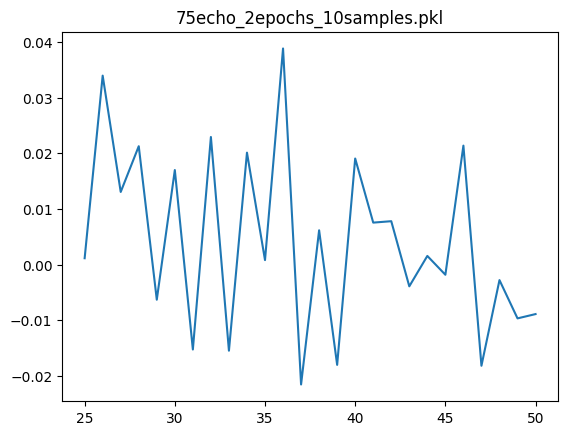

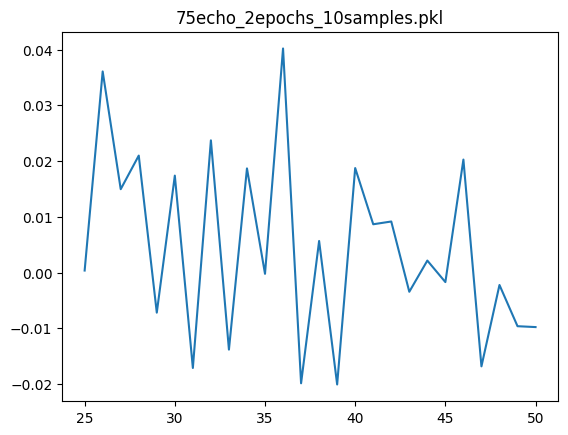

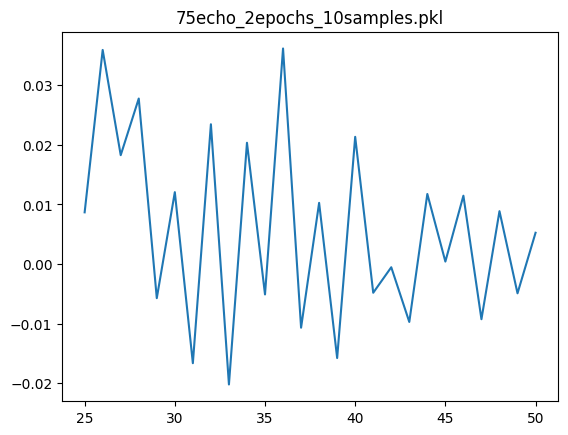

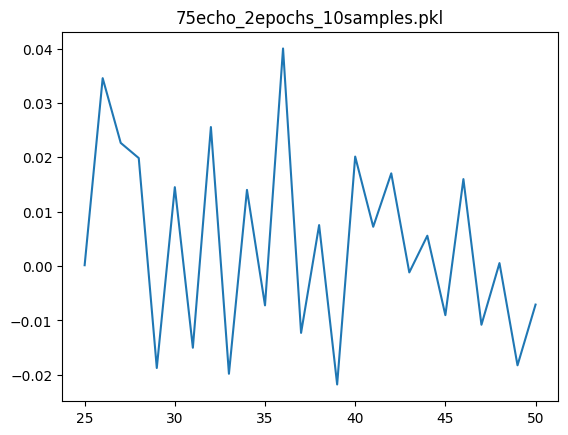

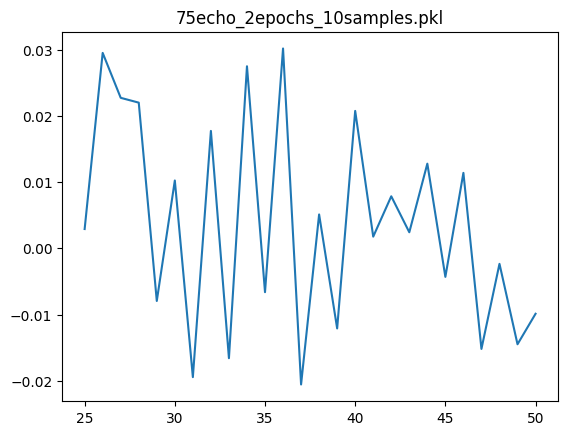

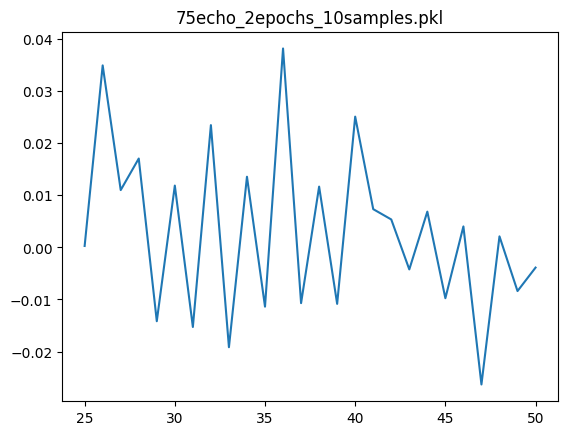

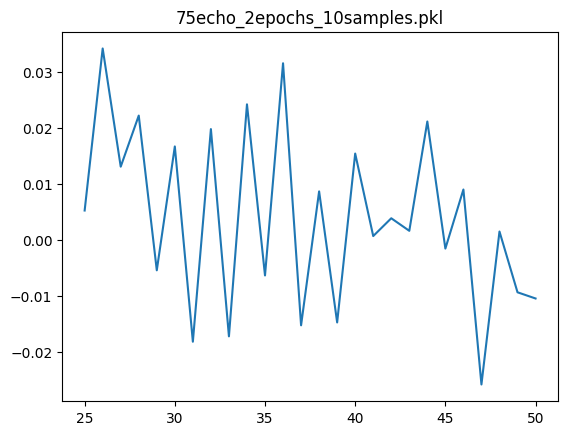

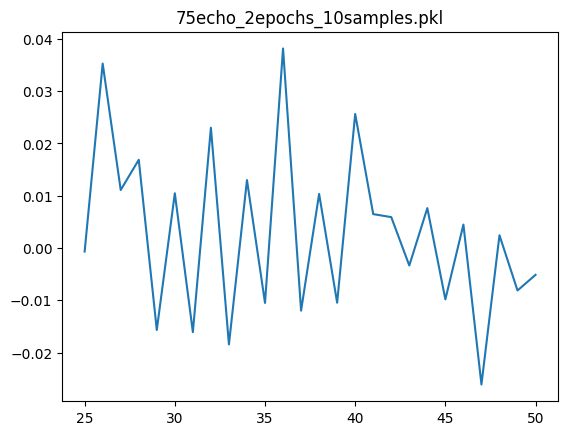

Doing other 75 5
Doing idx 0 file /home/tomek/datasets/GuitarSet/05_Jazz1-130-D_comp_mic.wav, 1/360, length 22 sec
Elapsed time pitch: 0.427980899810791
Elapsed time synth: 0.5090005397796631


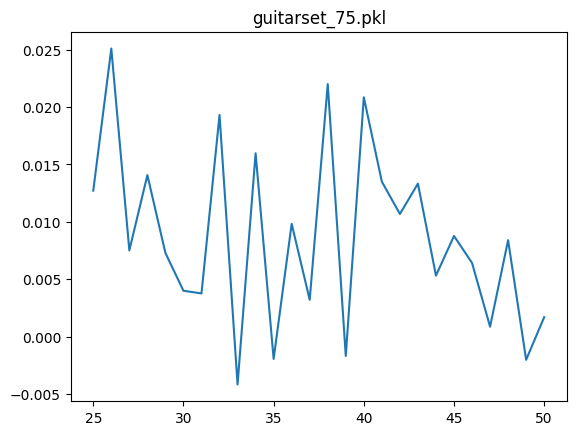

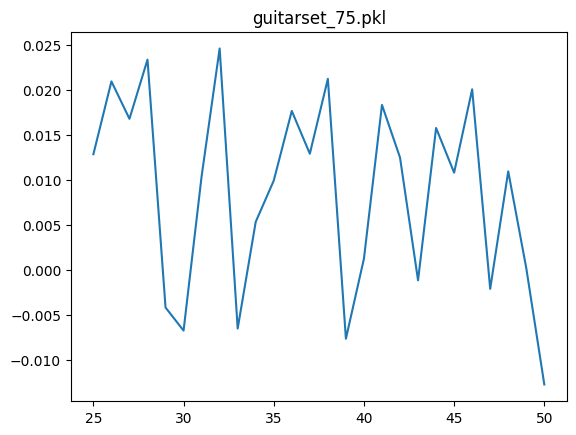

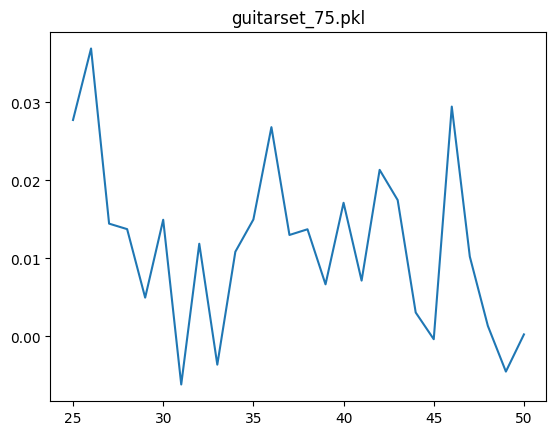

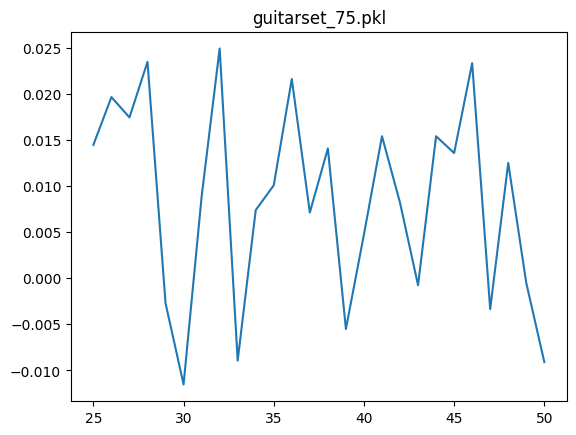

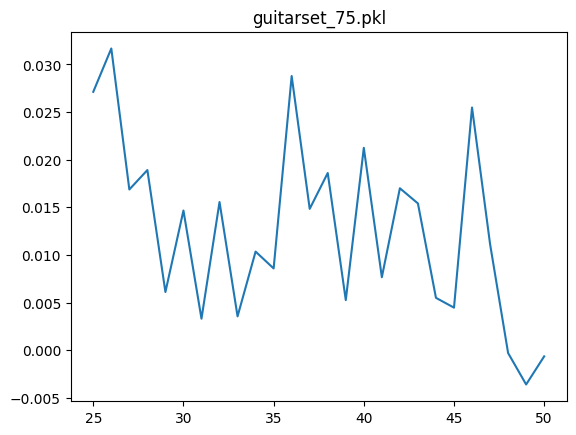

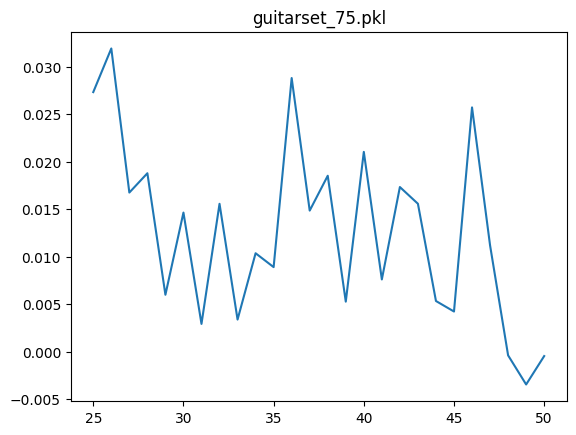

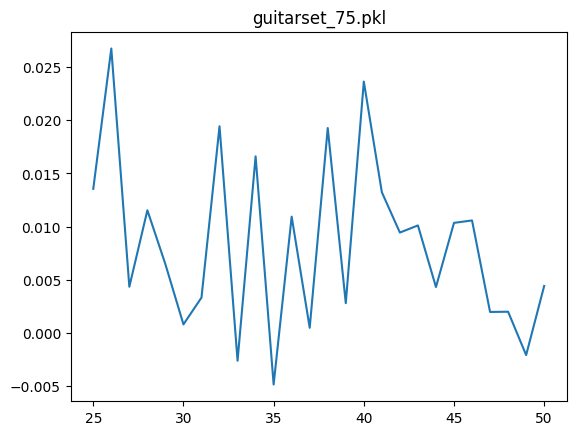

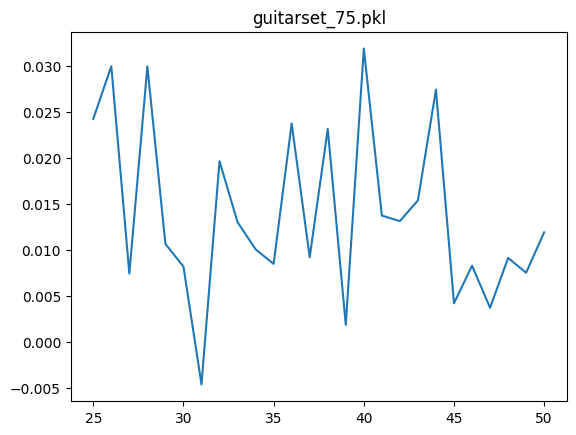

Doing other 75 5
Doing idx 0 file /home/tomek/datasets/GuitarSet/05_Jazz1-130-D_comp_mic.wav, 1/360, length 22 sec
Elapsed time pitch: 0.428560733795166
Elapsed time synth: 0.5032598972320557


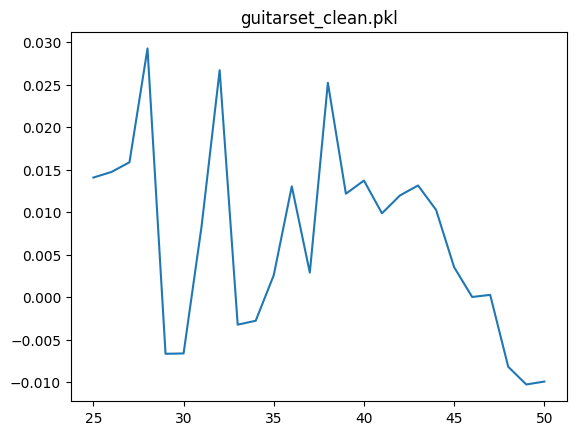

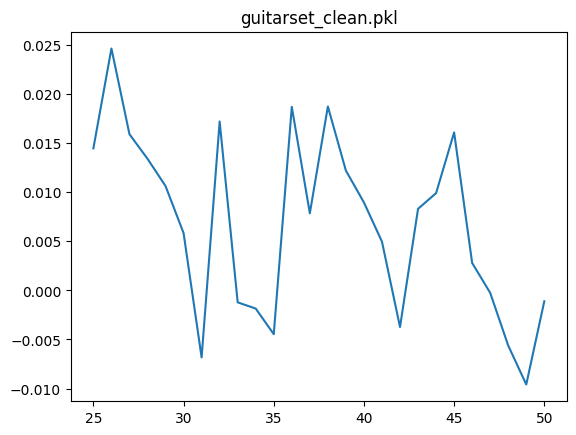

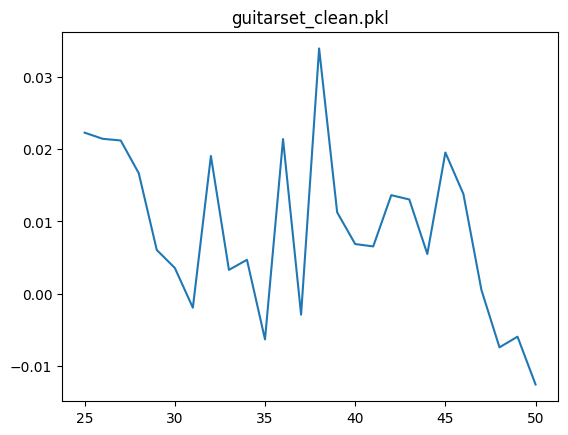

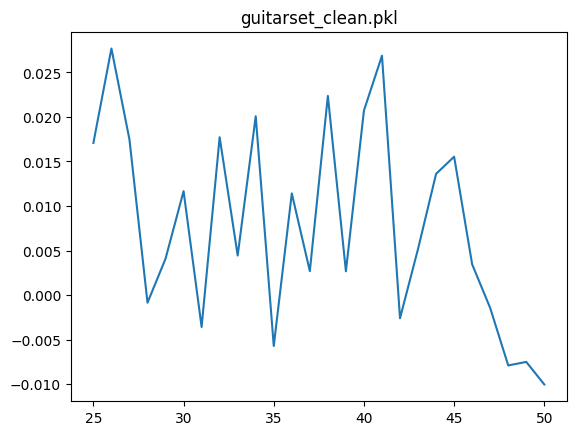

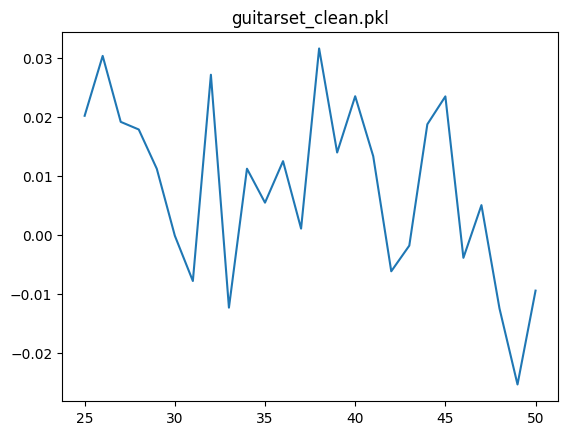

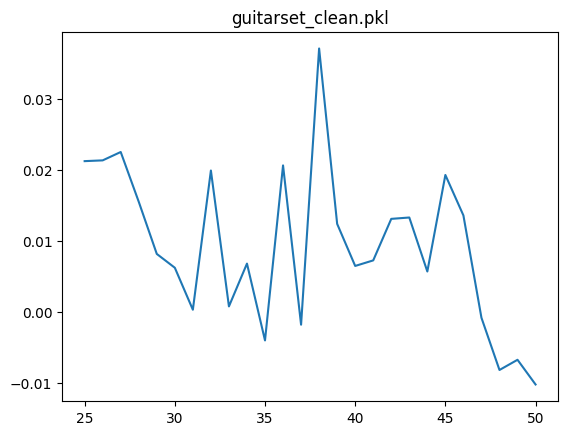

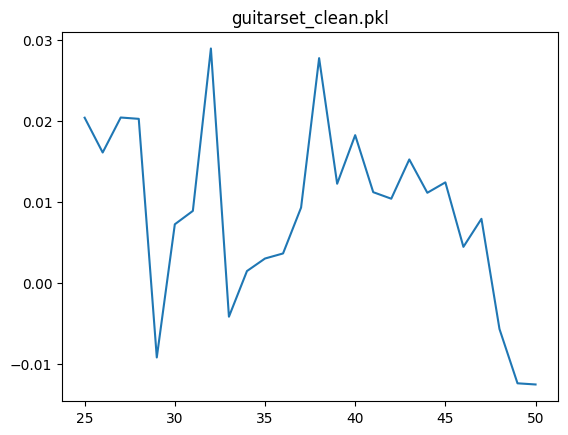

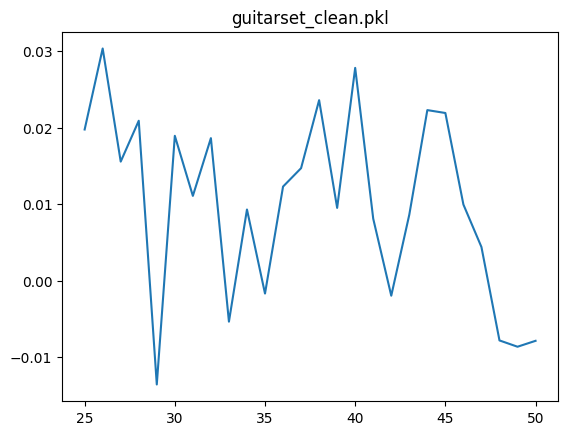

In [ ]:
from pathlib import Path
import torch
import librosa
import soundfile
import numpy as np
import sys
sys.path.append("/home/tomek/github/Audio2AudioEchoes/ddsp")
sys.path.append("/home/tomek/github/Audio2AudioEchoes/src")
from model import DDSPDecoder
import glob
import json
import os
from tqdm import tqdm
from collections import defaultdict
import argparse
import itertools
from multiprocessing import Pool
from matplotlib import pyplot as plt

from echohiding import get_cepstrum, get_z_score

## Define parameter variations
instruments = ["other"]
echoes = [75]
durs = [5]#, 10, 30, 60]


def eval_echo_models(param, model_path):
    """
    Z-score evaluation for single echo style transfer 
    """
    (idx, opt) = param
    (instrument, echo, dur) = list(itertools.product(instruments, echoes, durs))[idx]
    out_path = f"evaluation/results/ddsp_{instrument}_{echo}_dur{dur}.json"
    dataset_pattern = "/home/tomek/datasets/GuitarSet/*.wav"
    print("Doing", instrument, echo, dur)

    torch.set_grad_enabled(False)
    files = glob.glob(dataset_pattern)
    sr = opt.sr
    
    results = {}
    if os.path.exists(out_path):
        results = json.load(open(out_path))
    if not os.path.exists(model_path):
        print(model_path, "doesn't exist!  Aborting")
        return
    
    model = DDSPDecoder(3, 512, 50, 65, 441, opt.sr, opt.sr)
    model.load_from_file(model_path)

    for fidx, f in [(0, files[5])]:
        torch.cuda.empty_cache()
        tune = f.split("/")[-1]
        if tune in results:
            print("Skipping", tune)
            continue
        else:
            results[tune] = defaultdict(lambda: [])
        x, _ = librosa.load(f, sr=sr)
        print(f"Doing idx {idx} file {f}, {fidx+1}/{len(files)}, length {x.size//sr} sec")
        with torch.no_grad():
            y = model.style_transfer(x, "cpu", "cuda")
            soundfile.write("out.wav",y,44100)
        if y.size < dur*sr:
            print(f, "too short for", dur)
            continue
        chunks_this_time = min(opt.n_chunks, 2*y.size//(dur*sr))
        for _ in range(chunks_this_time):
            i1 = np.random.randint(y.size-dur*sr) # Choose a random offset
            cep = get_cepstrum(y[i1:i1+sr*dur])
            csort = np.array(cep[0:opt.lag_end+1])
            plt.plot(range(opt.lag_start, opt.lag_end+1), csort[opt.lag_start:])
            plt.title(Path(model_path).name)
            plt.show()
            # csort[0:opt.lag_start] = -np.inf
            # ranks = np.zeros(csort.size)
            # ranks[np.argsort(-csort)] = np.arange(csort.size)
            # for test_echo in echoes:
            #     if test_echo == "clean":
            #         continue
            #     z = get_z_score(cep[0:opt.lag_end+1], test_echo, start_buff=opt.lag_start)
            #     results[tune][f"z_{test_echo}"].append(z)
            #     results[tune][f"rank_{test_echo}"].append(int(ranks[test_echo]))
        #json.dump(results, open(out_path, "w"))



if __name__ == '__main__':
    # parser = argparse.ArgumentParser()
    # parser.add_argument("--min", type=int, default=0, help="Minimum index of experiment to run")
    # parser.add_argument("--max", type=int, default=1, help="Maximum index of experiment to run")
    # parser.add_argument('--n_chunks', type=int, default=100, help="Max number of chunks to compute for each clip for each duration")
    # parser.add_argument('--sr', type=int, default=44100, help="Audio sample rate")
    # parser.add_argument("--lag_start", type=int, default=25, help="First index to use when computing z-score")
    # parser.add_argument("--lag_end", type=int, default=150, help="Last index to use when computing z-score")
    #opt = parser.parse_args()

    model_path1 = "/home/tomek/github/Audio2AudioEchoes/finetune_outputs/ddsp/75echo_2epochs_10samples.pkl"
    model_path2 = "/home/tomek/github/Audio2AudioEchoes/ArtistProtectModels/SingleEchoes/DDSP/guitarset_75.pkl"
    model_path3 = "/home/tomek/github/Audio2AudioEchoes/ArtistProtectModels/SingleEchoes/DDSP/guitarset_clean.pkl"

    opt = argparse.Namespace(min=0,max=1,n_chunks=100,sr=44100,lag_start=25,lag_end=50)

    for i in range(opt.min, opt.max):
        for model in (model_path1,model_path2,model_path3):
            eval_echo_models((i, opt),model)